In [1]:
!pip install transformers==5.3.0
!pip install git+https://github.com/huggingface/diffusers@v0.38.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 14.4 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 13.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 17.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 17.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.2/801.2 kB 8.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [transformers] [transformers]ub]
  Cloning https://github.com/huggingface/diffusers (to revision v0.38.0) to /tmp/pip-req-build-ftd2e4ko
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers /tmp/pip-req-build-ftd2e4ko
  Running command git checkout -q 7a4825ef0d44645ab0c6046d665477f383932993
  Resolved https://github.com/huggingface/diffusers to commit 7a4825ef0d44645ab0c6046d665477f383932993
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata 

In [2]:
!pip install accelerate peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 8.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [peft]1/2 [peft]


In [ ]:
from diffusers import DiffusionPipeline
import torch

model_name = "Qwen/Qwen-Image-2512"

# Load the pipeline
if torch.cuda.is_available():
    torch_dtype = torch.bfloat16
    device = "cuda"
else:
    torch_dtype = torch.float32
    device = "cpu"

pipe = DiffusionPipeline.from_pretrained(model_name, torch_dtype=torch_dtype).to(device)

# Generate image
prompt = '''A 20-year-old East Asian girl with delicate, charming features and large, bright brown eyes—expressive and lively, with a cheerful or subtly smiling expression. Her naturally wavy long hair is either loose or tied in twin ponytails. She has fair skin and light makeup accentuating her youthful freshness. She wears a modern, cute dress or relaxed outfit in bright, soft colors—lightweight fabric, minimalist cut. She stands indoors at an anime convention, surrounded by banners, posters, or stalls. Lighting is typical indoor illumination—no staged lighting—and the image resembles a casual iPhone snapshot: unpretentious composition, yet brimming with vivid, fresh, youthful charm.'''

negative_prompt = "低分辨率，低画质，肢体畸形，手指畸形，画面过饱和，蜡像感，人脸无细节，过度光滑，画面具有AI感。构图混乱。文字模糊，扭曲。"


# Generate with different aspect ratios
aspect_ratios = {
    "1:1": (1328, 1328),
    "16:9": (1664, 928),
    "9:16": (928, 1664),
    "4:3": (1472, 1104),
    "3:4": (1104, 1472),
    "3:2": (1584, 1056),
    "2:3": (1056, 1584),
}

width, height = aspect_ratios["16:9"]

image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    width=width,
    height=height,
    num_inference_steps=50,
    true_cfg_scale=4.0,
    generator=torch.Generator(device="cuda").manual_seed(42)
).images[0]

image.save("example.png")


model_index.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

Fetching 27 files:   0%|          | 0/27 [00:00<?, ?it/s]

In [2]:
1

1

In [4]:
negative_prompt


'低分辨率，低画质，肢体畸形，手指畸形，画面过饱和，蜡像感，人脸无细节，过度光滑，画面具有AI感。构图混乱。文字模糊，扭曲。'

In [5]:
width, height = aspect_ratios["16:9"]
prompt='A kitchen scene with: broccoli, plum, fillet, chopping_board, bread, pan, capsicum'
negative_prompt = 'milk pack'
image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    width=width,
    height=height,
    num_inference_steps=50,
    true_cfg_scale=4.0,
    generator=torch.Generator(device="cuda").manual_seed(42)
).images[0]


  0%|          | 0/50 [00:00<?, ?it/s]

A kitchen scene with: broccoli, plum, fillet, chopping_board, bread, pan, capsicum


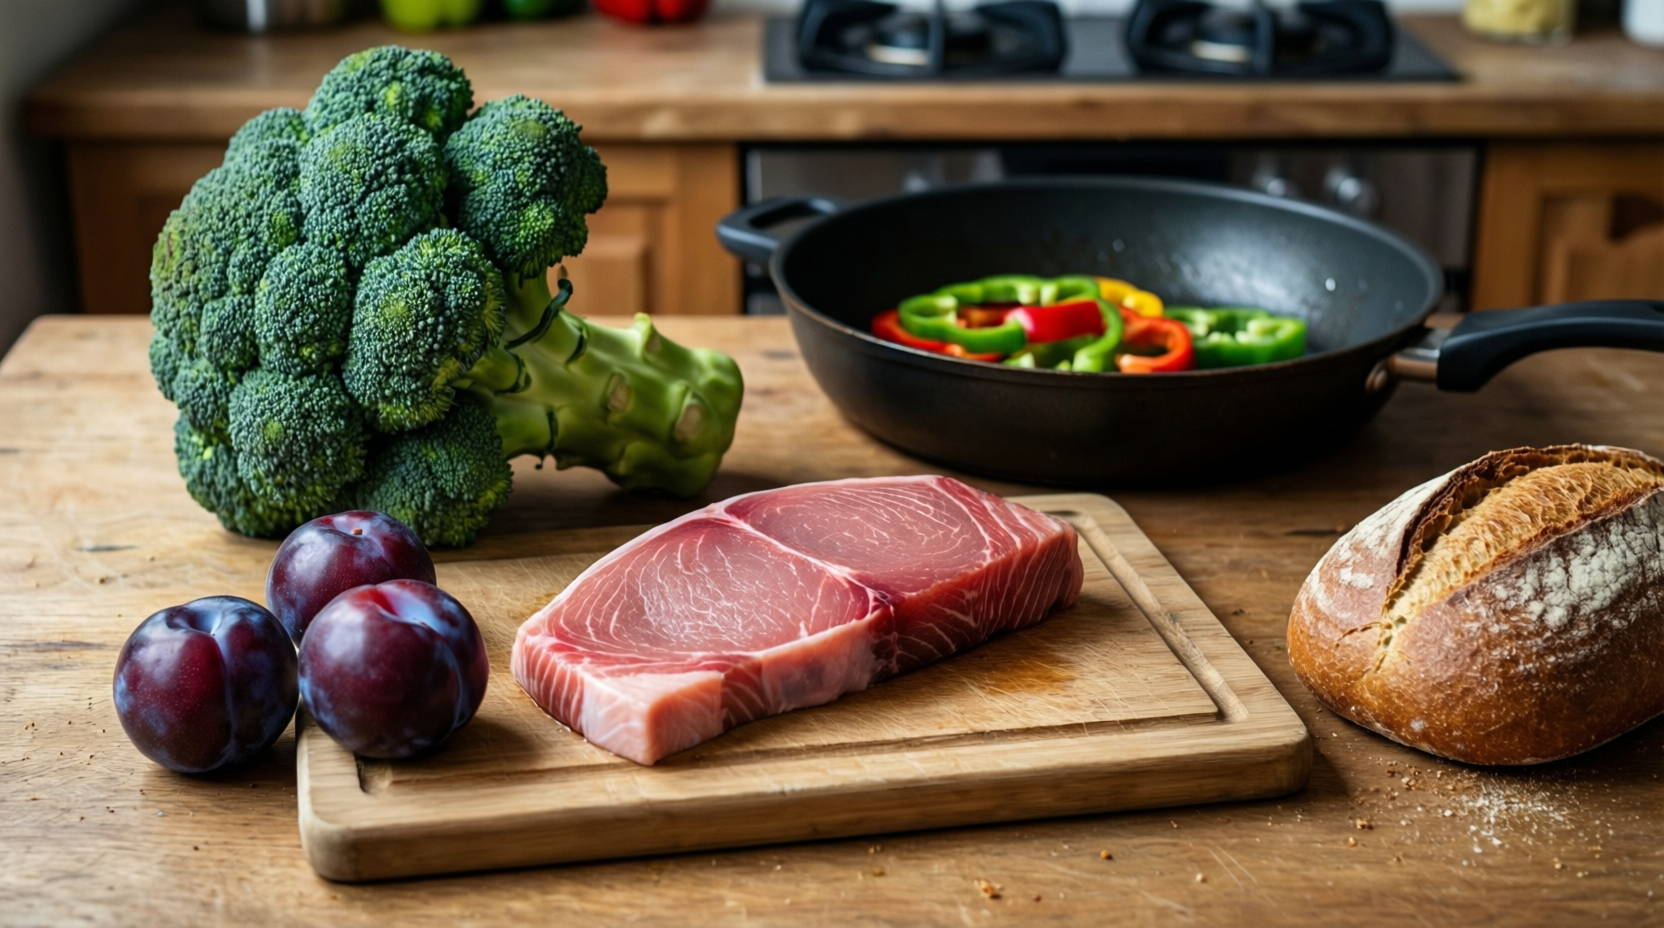

In [7]:
print(prompt)
image

  0%|          | 0/10 [00:00<?, ?it/s]

A kitchen scene with: broccoli, plum, fillet, chopping_board, bread, pan, capsicum


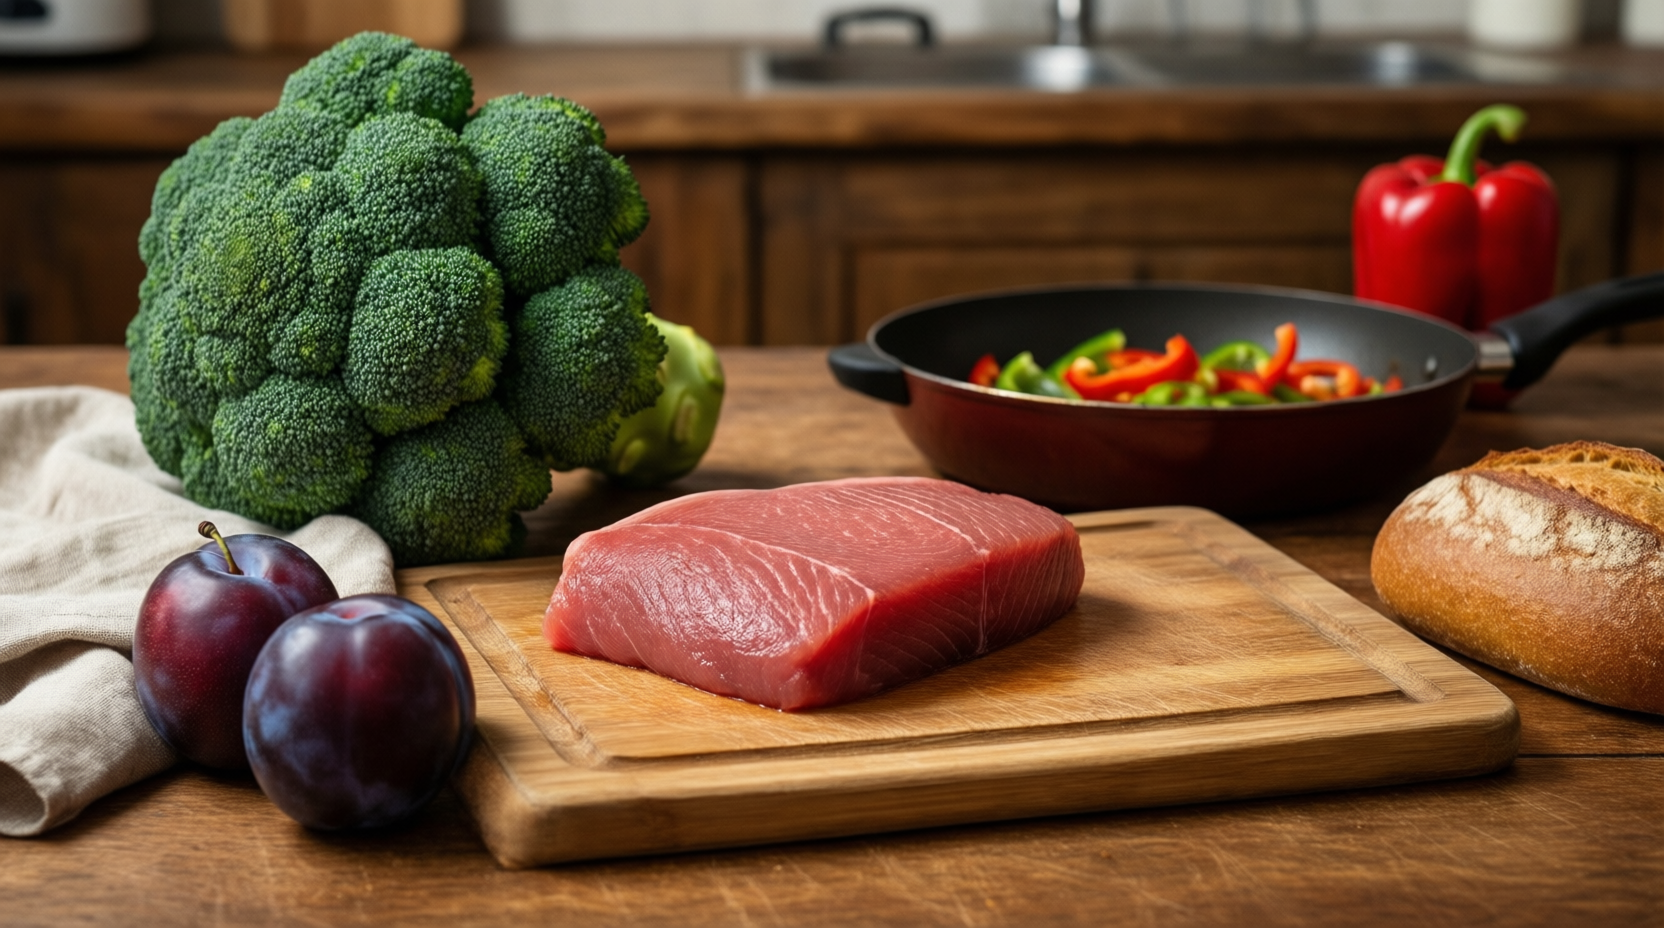

In [8]:
width, height = aspect_ratios["16:9"]
prompt='A kitchen scene with: broccoli, plum, fillet, chopping_board, bread, pan, capsicum'
negative_prompt = 'milk pack'
image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    width=width,
    height=height,
    num_inference_steps=10,
    true_cfg_scale=4.0,
    generator=torch.Generator(device="cuda").manual_seed(42)
).images[0]
print(prompt)
image

In [12]:
pipe.encode_prompt(prompt)[0].shape

torch.Size([1, 26, 3584])

In [40]:
!pip install torchmetrics>=1.4.0

In [14]:
from torchmetrics.multimodal import clip_iqa, clip_score

In [26]:
help(clip_score.CLIPScore)

Help on class CLIPScore in module torchmetrics.multimodal.clip_score:

class CLIPScore(torchmetrics.metric.Metric)
 |  CLIPScore(model_name_or_path: Union[Literal['openai/clip-vit-base-patch16', 'openai/clip-vit-base-patch32', 'openai/clip-vit-large-patch14-336', 'openai/clip-vit-large-patch14', 'jinaai/jina-clip-v2', 'zer0int/LongCLIP-L-Diffusers', 'zer0int/LongCLIP-GmP-ViT-L-14'], Callable[[], tuple[None, None]]] = 'openai/clip-vit-large-patch14', **kwargs: Any) -> None
 |
 |  Calculates `CLIP Score`_ which is a text-to-image similarity metric.
 |
 |  CLIP Score is a reference free metric that can be used to evaluate the correlation between a generated caption for
 |  an image and the actual content of the image, as well as the similarity between texts or images. It has been found
 |  to be highly correlated with human judgement. The metric is defined as:
 |
 |  .. math::
 |      \text{CLIPScore(I, C)} = max(100 * cos(E_I, E_C), 0)
 |
 |  which corresponds to the cosine similarity be

In [20]:
!pip install einops
!pip install timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 41.5 MB/s  0:00:00


In [25]:
s = clip_score.CLIPScore('jinaai/jina-clip-v2', device='cuda')

ValueError: Unexpected keyword arguments: `device`

In [15]:
help(clip_score)

Help on module torchmetrics.multimodal.clip_score in torchmetrics.multimodal:

NAME
    torchmetrics.multimodal.clip_score

DESCRIPTION
    # Copyright The Lightning team.
    #
    # Licensed under the Apache License, Version 2.0 (the "License");
    # you may not use this file except in compliance with the License.
    # You may obtain a copy of the License at
    #
    #     http://www.apache.org/licenses/LICENSE-2.0
    #
    # Unless required by applicable law or agreed to in writing, software
    # distributed under the License is distributed on an "AS IS" BASIS,
    # WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
    # See the License for the specific language governing permissions and
    # limitations under the License.

CLASSES
    torchmetrics.metric.Metric(torch.nn.modules.module.Module, abc.ABC)
        CLIPScore

    class CLIPScore(torchmetrics.metric.Metric)
     |  CLIPScore(model_name_or_path: Union[Literal['openai/clip-vit-base-patch16', 'o

In [23]:
metric = clip_score.CLIPScore(model_name_or_path="openai/clip-vit-base-patch16")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [34]:
from torchvision.transforms.functional import pil_to_tensor

In [35]:
metric(pil_to_tensor(image),  'prompt')

AttributeError: 'BaseModelOutputWithPooling' object has no attribute 'norm'

In [37]:
score = metric("28-year-old chef found dead in San Francisco mall",
               "A 28-year-old chef who recently moved to San Francisco was found dead.")

AttributeError: 'BaseModelOutputWithPooling' object has no attribute 'norm'

In [38]:
metric.update(torch.randint(255, (3, 224, 224)), "a photo of a cat")

AttributeError: 'BaseModelOutputWithPooling' object has no attribute 'norm'

In [41]:
from torchmetrics import __version__
__version__

'1.9.0'

In [49]:
from transformers import __version__
__version__

'5.3.0'

In [51]:
!pip install transformers==4.36.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 56.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 24.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 60.0 MB/s  0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.7.2
    Uninstalling huggingface_hub-1.7.2:
      Successfully uninstalled huggingface_hub-1.7.2
  Attempting uninstall: tokenizers━━━━━━━━━━━━━━ 0/3 [huggingface-hub]
    Found existing installation: tokenizers 0.22.20/3 [huggingface-hub]
    Uninstalling tokenizers-0.22.2:━━━━━━━━━ 0/3 [huggingface-hub]
      Successfully uninstalled tokenizers-0.22.2 0/3 [huggingface-hub]
  Attempting uninstall: transformers━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [tokenizers]
    Found existing installation: transformers 5.3.0━━━━━━━━━━━ 1/3 [tokenizers]
    Uninstalling transformers-5.3.0:0m╸━━━━━━━━━━━━━ 2/3 [transformers]
      Successfully uninstalled transformers-5.3.0━━━━━━━━━━━━━ 2/3 [trans

In [1]:
from torchmetrics.multimodal import clip_iqa, clip_score
metric = clip_score.CLIPScore(model_name_or_path="openai/clip-vit-base-patch16")
score = metric("28-year-old chef found dead in San Francisco mall",
               "A 28-year-old chef who recently moved to San Francisco was found dead.")

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [53]:
image.save('q.png')

In [2]:
score

tensor(91.3950, grad_fn=<CloneBackward0>)